In [1]:
# 라이브러리 로딩
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import MinMaxScaler
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam


# 디바이스 준비
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size = 32) :
    # 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)


    # TensorDataset 생성: 텐서 데이터 세트로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)


    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)
    return train_loader, x_val_tensor, y_val_tensor

In [3]:
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset) # 전체 데이터 세트의 크기
    num_batches = len(dataloader) # 배치 크기
    tr_loss = 0


    model.train() # 학습 모드로 설정
    for x, y in dataloader: # 배치 단위로 로딩
        x, y = x.to(device), y.to(device) # 디바이스 지정


        # Feed Forward(오차 순전파)
        pred = model(x)
        loss = loss_fn(pred, y)
        tr_loss += loss


        # Backpropagation(오차 역전파)
        loss.backward() # 역전파를 통해 각 파라미터에 대한 오차의 기울기 계산
        optimizer.step() # 옵티마이저가 모델의 파라미터를 업데이트
        optimizer.zero_grad() # 옵티마이저의 기울기값 초기화.


    tr_loss /= num_batches # 모든 배치의 오차 평균
    return tr_loss.item()

In [4]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval() # 모델을 평가 모드로 설정


    with torch.no_grad(): # 평가 과정에서 기울기를 계산하지 않도록 설정
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item() # 예측값 pred와 목푯값 y 사이의 오차 계산


    return eval_loss, pred

In [5]:
def dl_learning_curve(tr_loss_list, val_loss_list):
    epochs = list(range(1, len(tr_loss_list)+1)) # 에포크 수 계산
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.') # 학습 오차 그래프
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.') # 검증 오차 그래프
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

In [6]:
path = 'https://bit.ly/irisdata_csv'
data = pd.read_csv(path)
data.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [7]:
target = 'Species'
x = data.drop(target, axis = 1)
y = data.loc[:, target]

In [8]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)
print(type(y))

<class 'numpy.ndarray'>


In [ ]:
# 앞에서 3개를 찍어라

y[:3]

array([0, 0, 0])

In [10]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [11]:
# 데이터 분할

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=.3, random_state=20)


# 스케일링
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)


# 데이터 로더
train_loader, x_val_ts, y_val_ts = make_DataSet(x_train, x_val, y_train, y_val, 32)

In [12]:
print(le.classes_)
y_orig = le.inverse_transform(y)

['setosa' 'versicolor' 'virginica']


In [ ]:
# 신경망 구성하기

n_feature = x.shape[1]      # .shape[1] : 컬럼의 수  => 입력층 갯수
n_class = len(le.classes_)  # 레이블의 클래수 수(답) => 출력층 갯수


# 모델 구조 설계
model = nn.Sequential(
            nn.Linear(n_feature, n_class),
            ).to(device)


In [14]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.1)

In [15]:
# 학습하기

epochs = 50
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f'Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}')

Epoch 1, train loss : 0.969499, val loss : 0.909158
Epoch 2, train loss : 0.742677, val loss : 0.823526
Epoch 3, train loss : 0.697590, val loss : 0.739272
Epoch 4, train loss : 0.576168, val loss : 0.627469
Epoch 5, train loss : 0.506908, val loss : 0.576669
Epoch 6, train loss : 0.468458, val loss : 0.549767
Epoch 7, train loss : 0.441454, val loss : 0.536470
Epoch 8, train loss : 0.430250, val loss : 0.504699
Epoch 9, train loss : 0.384609, val loss : 0.478761
Epoch 10, train loss : 0.377187, val loss : 0.468651
Epoch 11, train loss : 0.345538, val loss : 0.477810
Epoch 12, train loss : 0.377287, val loss : 0.464269
Epoch 13, train loss : 0.340535, val loss : 0.436170
Epoch 14, train loss : 0.338405, val loss : 0.426459
Epoch 15, train loss : 0.317930, val loss : 0.430656
Epoch 16, train loss : 0.344015, val loss : 0.428129
Epoch 17, train loss : 0.319544, val loss : 0.408347
Epoch 18, train loss : 0.301273, val loss : 0.404502
Epoch 19, train loss : 0.269808, val loss : 0.398681
Ep

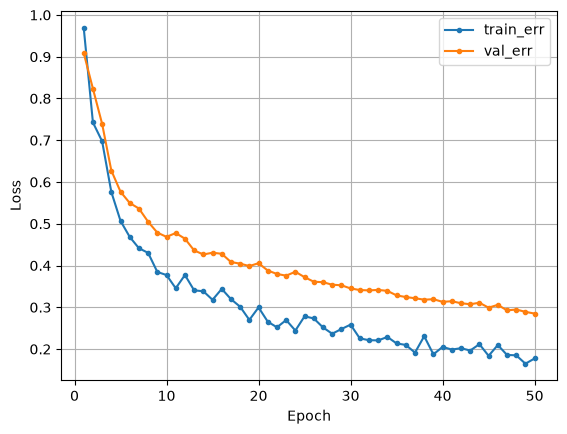

In [16]:
# 시각화

dl_learning_curve(tr_loss_list, val_loss_list)

In [18]:
##### [실습 2] 다중 분류 모델링 실습 - MNIST(손글씨) #####

In [19]:
from torchvision import datasets
from torchvision.transforms import ToTensor


train_dataset = datasets.MNIST(
    root='data',
    train=True,
    download=True,
    transform=ToTensor() )
test_dataset = datasets.MNIST(
    root='data',
    train=False,
    download=True,
    transform=ToTensor() )

In [20]:
train_dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [ ]:
# 차원 확인하기 : 3차원 임
# 이미지 데이터

train_dataset.data.shape

torch.Size([60000, 28, 28])

In [ ]:
# 레이블 = 답 (이미지 하나에 답 하나씩 확인됨)

train_dataset.targets.shape

torch.Size([60000])

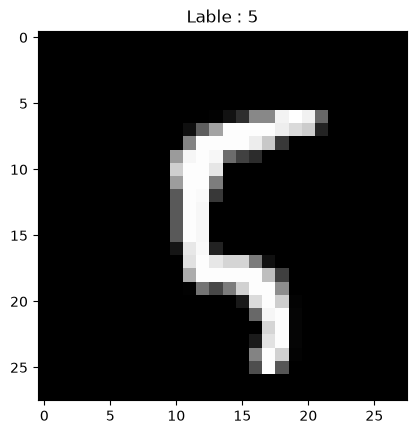

In [25]:
# 한장 이미지 출력

n = 100
image, label = train_dataset.data[n], train_dataset.targets[n]

# 이미지 시각화
plt.imshow(image, cmap='gray')
plt.title(f'Lable : {label}')
plt.show()

In [26]:
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size)

In [27]:
x_val, x_test = test_dataset.data[:5000], test_dataset.data[5000:]
y_val, y_test = test_dataset.targets[:5000], test_dataset.targets[5000:]
x_val.shape, y_val.shape

(torch.Size([5000, 28, 28]), torch.Size([5000]))

In [28]:
# MinMax

x_val = x_val / 255
x_test = x_test / 255

In [29]:
x_val = x_val.view(5000, 1, 28, 28)     # 4차원 변경
x_test = x_test.view(5000, 1, 28, 28)   # 4차원 변경
print(x_val.shape, x_test.shape)

torch.Size([5000, 1, 28, 28]) torch.Size([5000, 1, 28, 28])


In [ ]:
n_feature = 28 * 28     # 입력층
n_class = 10            # 출력층


# 모델 구조 설계
model = nn.Sequential(nn.Flatten(),     # ⭐.Flatten : 1차원 변경 (28*28 => 784로 변경)
    nn.Linear(n_feature, n_class)
    ).to(device)


loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

In [31]:
# 학습하기

epochs = 10
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val, y_val, model, loss_fn, device)
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f'Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}')

Epoch 1, train loss : 0.549021, val loss : 0.427254
Epoch 2, train loss : 0.328428, val loss : 0.378285
Epoch 3, train loss : 0.299747, val loss : 0.360142
Epoch 4, train loss : 0.286018, val loss : 0.351098
Epoch 5, train loss : 0.277553, val loss : 0.345899
Epoch 6, train loss : 0.271625, val loss : 0.342634
Epoch 7, train loss : 0.267146, val loss : 0.340466
Epoch 8, train loss : 0.263591, val loss : 0.338974
Epoch 9, train loss : 0.260669, val loss : 0.337930
Epoch 10, train loss : 0.258207, val loss : 0.337199


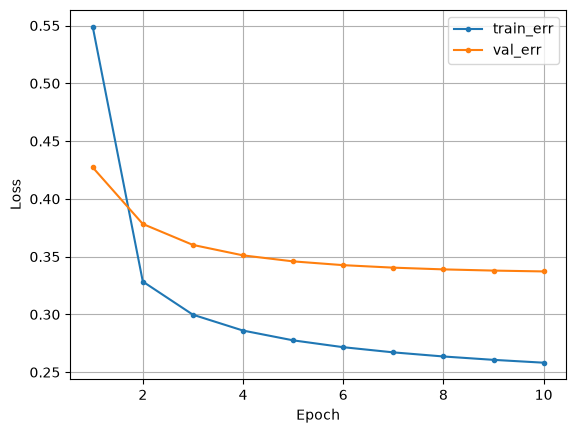

In [32]:
# 학습 곡선
dl_learning_curve(tr_loss_list, val_loss_list)

In [ ]:
# 수동으로 답 값 확인

_, pred = evaluate(x_test, y_test, model, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
print(pred[:5])

tensor([[1.1930e-03, 7.4280e-06, 8.1904e-04, 6.2054e-01, 4.2322e-04, 3.7263e-01,
         3.1959e-06, 9.7806e-06, 3.7003e-03, 6.6641e-04],
        [2.8091e-04, 7.2845e-08, 3.4723e-03, 8.9058e-03, 2.7372e-01, 4.0217e-03,
         3.4417e-04, 3.8140e-03, 2.3179e-01, 4.7364e-01],
        [7.7526e-07, 2.8789e-11, 1.4202e-07, 1.5998e-06, 5.0264e-03, 1.3980e-06,
         1.1300e-07, 8.3264e-04, 2.4634e-03, 9.9167e-01],
        [2.2778e-07, 1.2928e-09, 9.7739e-07, 5.1874e-06, 3.1038e-07, 2.8293e-04,
         9.8612e-09, 2.4919e-08, 9.9924e-01, 4.7229e-04],
        [7.0470e-05, 6.5572e-12, 3.5498e-06, 1.0958e-07, 9.9845e-01, 2.3660e-05,
         5.4784e-05, 2.9651e-05, 1.4505e-04, 1.2195e-03]], device='cuda:0')


In [ ]:
# 자동으로 답 확인

pred = np.argmax(pred.cpu().numpy(), axis = 1)
print(pred[:5])

[3 9 9 8 4]


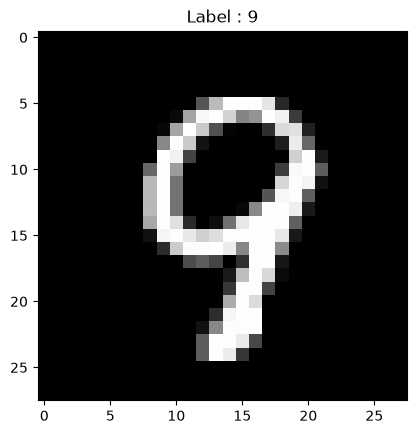

In [36]:
# x_test
# [5000 -> 3, 5001 -> 9, 5002 -> 9 8 4]

n = 1
image, label = test_dataset.data[ 5000 + n ], test_dataset.targets[ 5000 + n ]
plt.imshow(image, cmap='gray')
plt.title(f'Label : {label}')
plt.show()

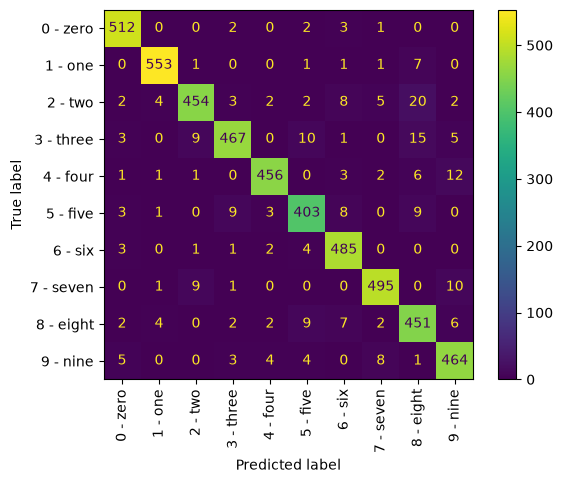

In [38]:
cm = confusion_matrix(y_test.numpy(), pred)
disp = ConfusionMatrixDisplay(cm, display_labels = train_dataset.classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

In [39]:
# 은닉층 추가

n_feature = 28 * 28
n_class = 10
# 모델 구조 설계
model = nn.Sequential(nn.Flatten(),
            nn.Linear(n_feature, 20), nn.ReLU(),
            nn.Linear(20, n_class)
            ).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

In [40]:
# 은닉층 추가 후 학습

epochs = 10
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val, y_val, model, loss_fn, device)
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f'Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}')

Epoch 1, train loss : 0.501256, val loss : 0.368106
Epoch 2, train loss : 0.264005, val loss : 0.313229
Epoch 3, train loss : 0.227962, val loss : 0.283437
Epoch 4, train loss : 0.204503, val loss : 0.261875
Epoch 5, train loss : 0.186267, val loss : 0.242558
Epoch 6, train loss : 0.171553, val loss : 0.227541
Epoch 7, train loss : 0.159456, val loss : 0.217497
Epoch 8, train loss : 0.149469, val loss : 0.210166
Epoch 9, train loss : 0.140960, val loss : 0.204065
Epoch 10, train loss : 0.133585, val loss : 0.199753


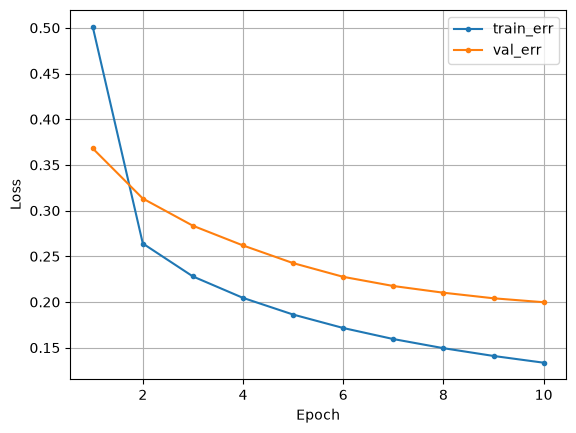

In [41]:
# 학습 곡선
dl_learning_curve(tr_loss_list, val_loss_list)